# LABORATORIO 04 - PROGRAMACION DINAMICA
## -Jerónimo Urrego Morales
## -Andrés Felipe Rubio Arango
## -Daniel Felipe Cárdenas Romero 

En este laboratorio trabajaremos con programacion dinamica. Haremos un programa que encuentre la menor cantidad de monedas necesarias para entregar un cambio determinado a un cliente.

## 1) Descripcion del problema:
Dar cambio con monedas colombianas.

Una tienda en Colombia necesita desarrollar un programa que calcule la menor cantidad de monedas necesarias para entregar un cambio determinado a un cliente, la tienda dispone de las siguientes monedas: monedas = [50, 100, 200, 500, 1000]

El usuario deberá ingresar el valor del cambio que necesita entregar.
Por ejemplo:
Ingrese el valor del cambio: 1850
El programa debe determinar cuál es la menor cantidad de monedas necesaria para completar exactamente ese valor.
Una posible solución sería:
1000 + 500 + 200 + 100 + 50 = 1850

Por lo tanto:
Cantidad mínima de monedas: 5
## 2) Requerimientos:
### Requerimientos Funcionales:

- El sistema debe permitir al usuario ingresar la cantidad total de productos a registrar. (n)
- El sistema debe permitir ingresar el código numérico de cada producto individualmente.
- El sistema debe ordenar los códigos ingresados de menor a mayor utilizando el algoritmo Merge Sort.
- El sistema debe mostrar la lista original (desordenada) y la lista resultante (ordenada).
- El sistema debe solicitar al usuario un código a buscar y utilizar Búsqueda Binaria para encontrarlo.
- El sistema debe informar claramente si el producto buscado fue encontrado o no.

### Requerimientos No funcionales:

- Usabilidad: El programa no se debe crashear si el usuario ingresa un valor no valido.
- Mantenibilidad: Codigo estructurado, modularizado en funciones.
- Eficiencia de tiempo: El ordenamiento debe ejecutarse en un tiempo de O(n log (n)) y la búsqueda en   O(log (n)).
- Interfaz: La interacción se realizará a través de la consola con mensajes claros.

## 3) Historias de Usuario:
#### Historia de Usuario 1: 
Como usuario (cajero), quiero ingresar el valor del cambio requerido para que el sistema calcule el despiece de monedas.

##### Criterios:
- 1:  El sistema debe aceptar solo números enteros. Si se ingresa $0$ o números negativos, el sistema debe mostrar un mensaje de error ("Error, el monto no puede ser negativo ni 0") y pedir de nuevo el dato.

#### Historia de Usuario 2: 
Como tienda, se quiere que el sistema calcule la cantidad mínima absoluta de monedas para un monto, para no quedarme sin monedas de baja denominación rápido.

##### Criterios:
- 1: Para el monto $1850$, el algoritmo debe retornar 5. Debe evaluar usando la tabla de memorización para asegurar la optimalidad.

#### Historia de Usuario 3: 
Como cajero, quiero saber si un monto solicitado no puede ser cubierto con el sistema de monedas actual para advertir al cliente.

##### Criterios:
- 1: Si el monto ingresado es $30$, el sistema calculará que no hay forma de formarlo y mostrará: "No es posible entregar ese cambio exacto con las monedas disponibles."

## 4) Diagramas de flujo:
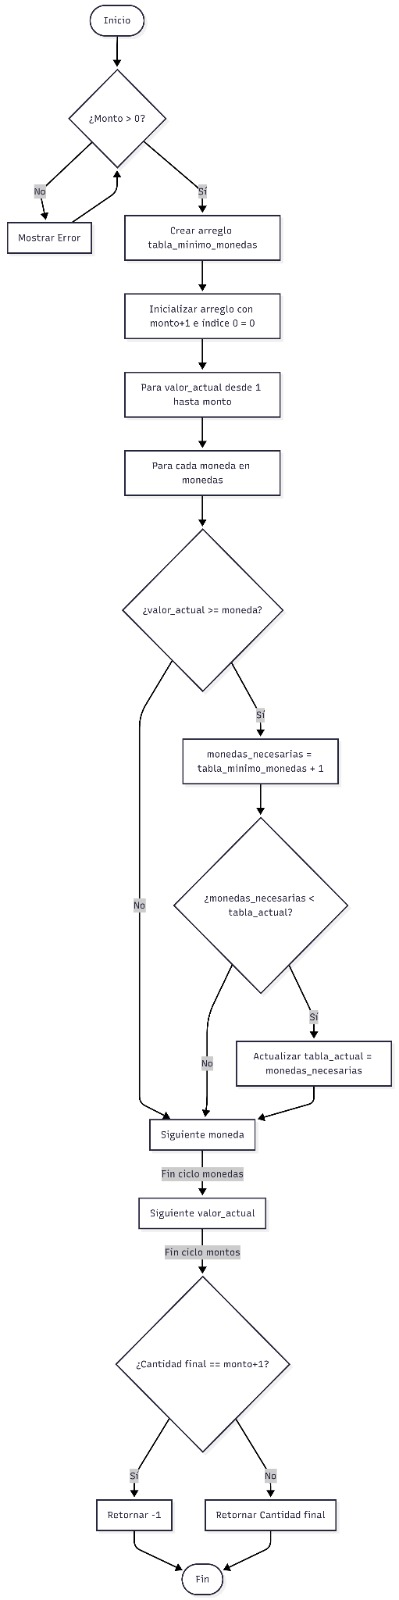

Este diagrama ilustra la lógica secuencial del algoritmo, destacando los bucles anidados donde ocurre la programación dinámica.

## 5) Diagramas de secuencia:
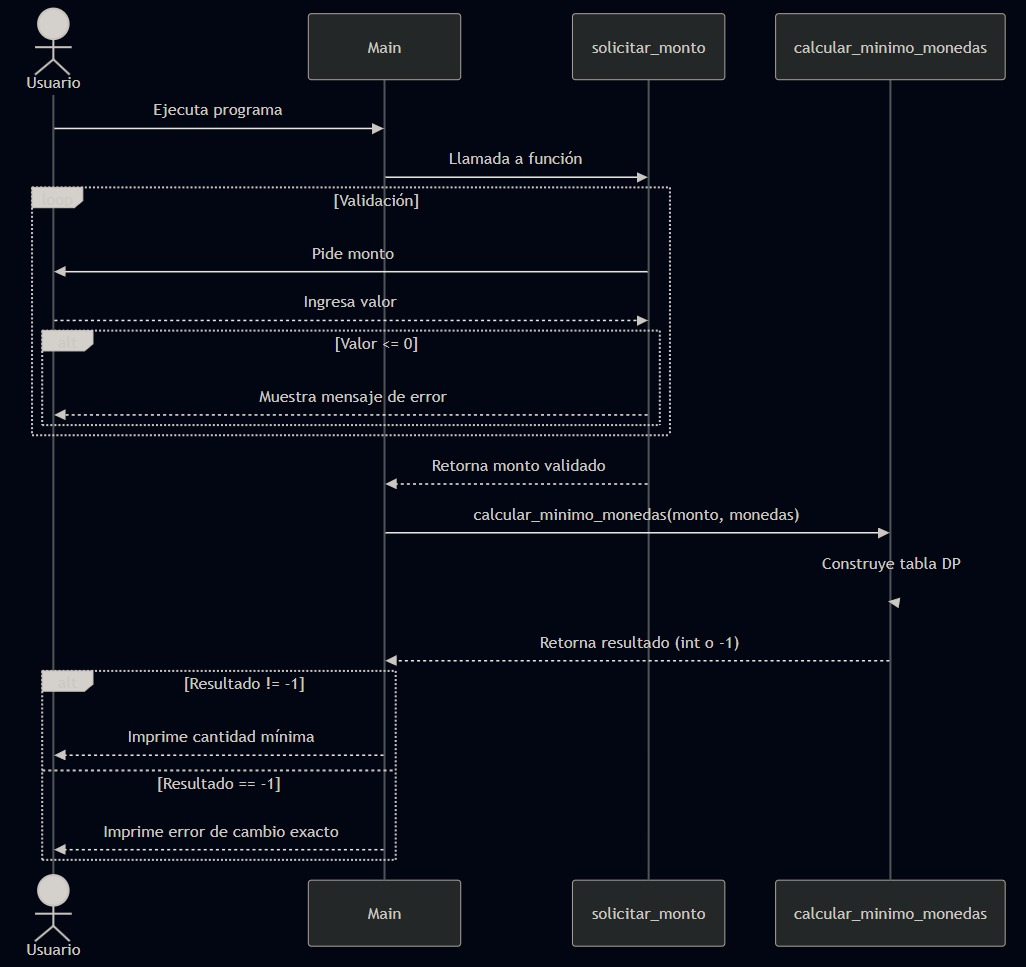
Este diagrama muestra la interacción de los componentes en tiempo de ejecución.

## 6) Diagramas de casos busqueda:
![WhatsApp Image 2026-08-20 at 5.18.01 PM.jpeg](<attachment:WhatsApp Image 2026-08-20 at 5.18.01 PM.jpeg>)
Muestra las funcionalidades desde la perspectiva de los actores del sistema.


## 7) Analisis de complejidad:
#### Programación dinámica:
##### Mejor y peor caso:
Al ser una tabla de programación dinámica, los bucles siempre recorren desde $1$ hasta $n$ sin sentencias de salida temprana (break).

Ecuación T(n):

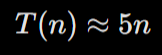

Esto puede verse tambien como una complejidad lineal ya que 5n sigue siendo n

Gráfica:

![WhatsApp Image 2026-08-20 at 5.27.25 PM.jpeg](<attachment:WhatsApp Image 2026-08-20 at 5.27.25 PM.jpeg>)


## 8 y 9) Codigo Funcional y pruebas
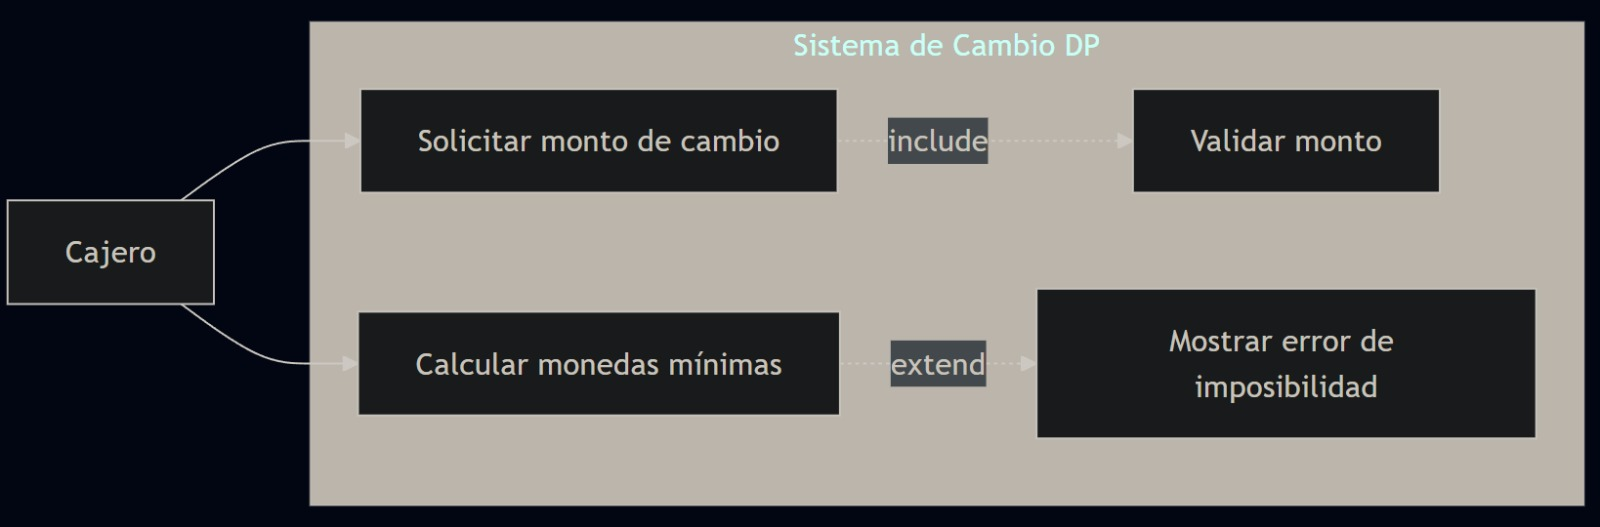
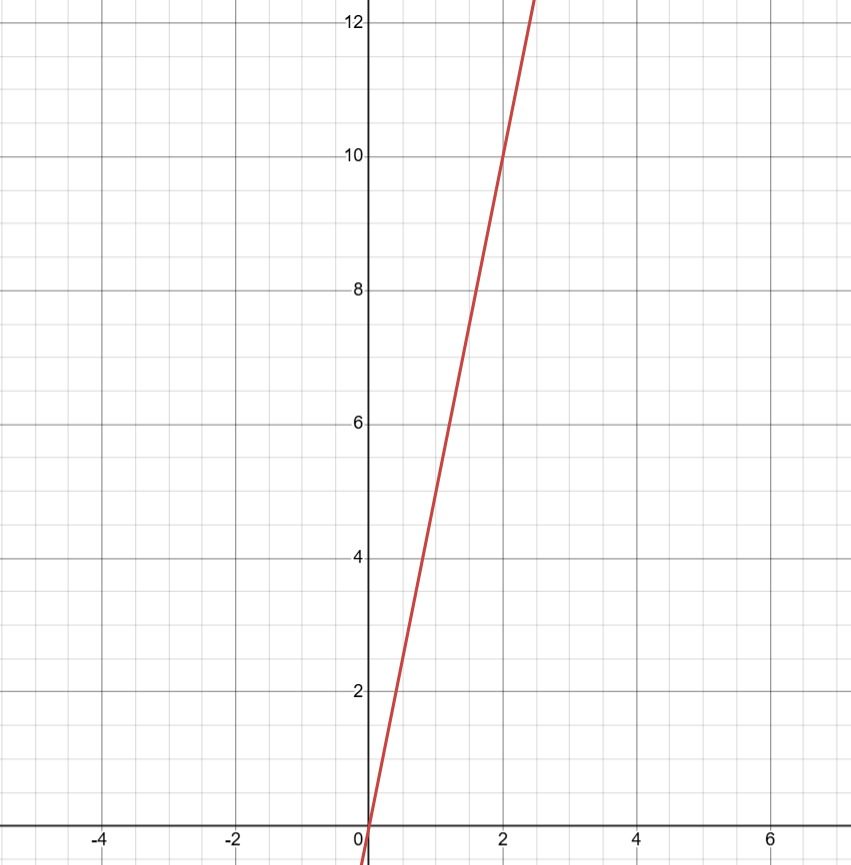

--- Pruebas de enunciado ---
Paso caso de prueba 1850 -> 5

--- Pruebas propias ---
Paso caso de prueba 50 -> 1
Paso caso de prueba 1350 -> 4
Paso caso de prueba 30 -> -1
Paso caso de prueba 2000 -> 2

Generando datos de benchmarking ... Listo!


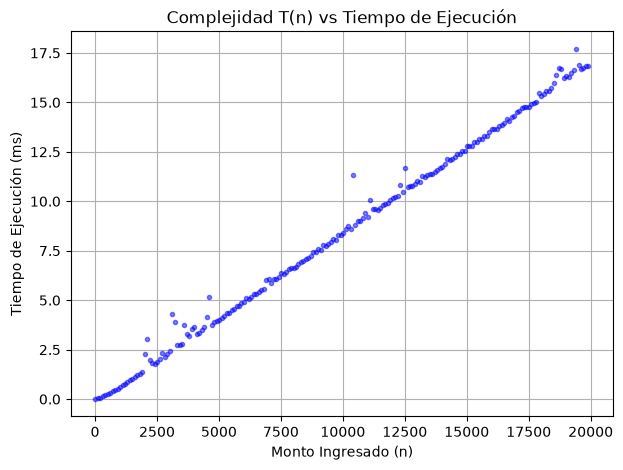


--- EJECUCIÓN INTERACTIVA ---
Cantidad mínima de monedas: 67


In [6]:
import time
import matplotlib.pyplot as plt

def solicitar_monto():
    monto = 0
    while monto <= 0:
        monto = int(input("Ingrese el monto para dar de vueltas sin puntos, espacios ni comas: "))
        if monto <= 0: 
            print("Error, el monto no puede ser negativo ni 0 ")
    return monto

def calcular_minimo_monedas(monto, monedas):
    valor_infinito = monto + 1
    tabla_minimo_monedas = [valor_infinito] * (monto + 1)
    tabla_minimo_monedas[0] = 0 # caso base
    
    # Calculamos la menor cantidad de monedas para cada valor desde 1 hasta el monto deseado
    for valor_actual in range(1, monto + 1):
        for moneda in monedas:
            if valor_actual >= moneda:
                monedas_necesarias = tabla_minimo_monedas[valor_actual - moneda] + 1
                if monedas_necesarias < tabla_minimo_monedas[valor_actual]:
                    tabla_minimo_monedas[valor_actual] = monedas_necesarias
                    
    # Si el valor no cambió, significa que no se pudo dar el cambio exacto
    cantidad_final = tabla_minimo_monedas[monto]
    if cantidad_final == valor_infinito:
        return -1
    return cantidad_final

def main():
    print("\n--- EJECUCIÓN INTERACTIVA ---")
    monedas_colombianas = [50, 100, 200, 500, 1000]
    monto = solicitar_monto()
    resultado = calcular_minimo_monedas(monto, monedas_colombianas)
    if resultado != -1:
        print(f"Cantidad mínima de monedas: {resultado}")
    else:
        print("No es posible entregar ese cambio exacto con las monedas disponibles.")

# ---- 2. SECCIÓN DE PRUEBAS UNITARIAS ----

def test(monto_input, expected_output, monedas):
    got_output = calcular_minimo_monedas(monto_input, monedas)
    assert got_output == expected_output, f"se obtuvo {got_output}, pero se esperaba {expected_output}"
    print(f"Paso caso de prueba {monto_input} -> {expected_output}")

def ejecutar_pruebas():
    monedas_colombianas = [50, 100, 200, 500, 1000]
    
    print("--- Pruebas de enunciado ---")
    test(1850, 5, monedas_colombianas) 

    print("\n--- Pruebas propias ---")
    test(50, 1, monedas_colombianas)      # Una sola moneda
    test(1350, 4, monedas_colombianas)    # 1000 + 200 + 100 + 50 = 4 monedas
    test(30, -1, monedas_colombianas)     # No hay monedas menores a 50
    test(2000, 2, monedas_colombianas)    # 1000 + 1000 = 2 monedas



# ---- 3. SECCIÓN DE BENCHMARKING (DESEMPEÑO) ----

def bench(n: int, step: int = 1) -> list[tuple[int, float]]:
    print("\nGenerando datos de benchmarking ...", end='')
    results: list[tuple[int, float]] = []
    monedas_colombianas = [50, 100, 200, 500, 1000]
    
    for size in range(10, n, step):
        ti = time.perf_counter()
        output = calcular_minimo_monedas(size, monedas_colombianas)
        tf = time.perf_counter()
        
        delta = (tf - ti) * 1000 # a milisegundos
        results.append((size, delta))
    print(" Listo!")
    return results

def dibujar(x, y, dimensiones=(7, 5)):
    assert len(x) == len(y)
    plt.figure(figsize=dimensiones)
    plt.plot(x, y, marker='.', linestyle='', alpha=0.5, color='blue')
    plt.title("Complejidad T(n) vs Tiempo de Ejecución")
    plt.xlabel("Monto Ingresado (n)")
    plt.ylabel("Tiempo de Ejecución (ms)")
    plt.grid(True)
    plt.show()

def ejecutar_benchmarking():
    # Medimos tiempos para montos desde 10 hasta 20,000 (saltos de 100)
    tiempos = bench(20000, step=100)
    x = [size for size, timing in tiempos]
    y = [timing for size, timing in tiempos]
    dibujar(x, y)

ejecutar_pruebas()
ejecutar_benchmarking()
main()